# Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importing the dataset and perform data preprocessing

In [ ]:
dataset = pd.read_csv("/content/CAR DETAILS FROM CAR DEKHO.csv")
dataset.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner


In [ ]:
dataset.shape

(4340, 8)

In [ ]:
dataset.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
dataset.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
print(dataset.fuel.value_counts())
print(dataset.seller_type.value_counts())
print(dataset.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


Encoding the categorical data

In [ ]:
# encoding 'fuel' column
dataset.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)

# encoding 'seller_type' column
dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)

# encoding 'transmission' column
dataset.replace({'transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipython-input-1290341553.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'fuel':{'Petrol':0,'Diesel':1,'CNG':2,'LPG':3,'Electric':4}},inplace=True)
/tmp/ipython-input-1290341553.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'seller_type':{'Dealer':0,'Individual':1,'Trustmark Dealer':2}},inplace=True)
/tmp/ipython-input-1290341553.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

In [ ]:
dataset.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,First Owner


In [ ]:
print(dataset.name.value_counts())

name
Maruti Swift Dzire VDI                            69
Maruti Alto 800 LXI                               59
Maruti Alto LXi                                   47
Hyundai EON Era Plus                              35
Maruti Alto LX                                    35
                                                  ..
Honda Brio 1.2 S Option MT                         1
Mahindra Bolero Power Plus Plus Non AC BSIV PS     1
Tata Indigo LS BSII                                1
Force One EX                                       1
Chevrolet Aveo 1.4 LT BSIV                         1
Name: count, Length: 1491, dtype: int64


In [ ]:
print(dataset.owner.value_counts())

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


In [ ]:
# Encoding the owner column
dataset.replace({'owner':{'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4}},inplace=True)


/tmp/ipython-input-2159421050.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.replace({'owner':{'First Owner':0,'Second Owner':1,'Third Owner':2,'Fourth & Above Owner':3,'Test Drive Car':4}},inplace=True)


In [ ]:
dataset.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0


# Split the dataset into input and output data

In [ ]:
x = dataset.drop(columns=[ 'selling_price'],axis=1)
y = dataset['selling_price']

In [ ]:
x.head(3)

,name,year,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,100000,1,1,0,0


# Split into training data and test data

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00


In [ ]:
# Encoding the 'name' column
from category_encoders import TargetEncoder

te = TargetEncoder(cols=['name'])

x_train_enc = te.fit_transform(x_train, y_train)
x_test_enc = te.fit_transform(x_test,y_test)


In [ ]:
x_test.head(3)

,name,year,km_driven,fuel,seller_type,transmission,owner
3978,Tata Manza Aqua Quadrajet BS IV,2010,80000,1,1,0,0
1448,Renault KWID RXT BSIV,2019,27000,0,1,0,0
2664,Hyundai Santro Xing GL Plus,2008,41723,0,1,0,1


# Model trainning(Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
lr.fit(x_train_enc, y_train)

LinearRegression()

# Model Evalution

In [ ]:
lr.score(x_test_enc,y_test)

0.7949691596884085

In [ ]:
lr.score(x_train_enc,y_train)

0.8243266223075711

In [ ]:
training_data_prediction = lr.predict(x_train_enc)

### Visualizing the actual price and the predicted price

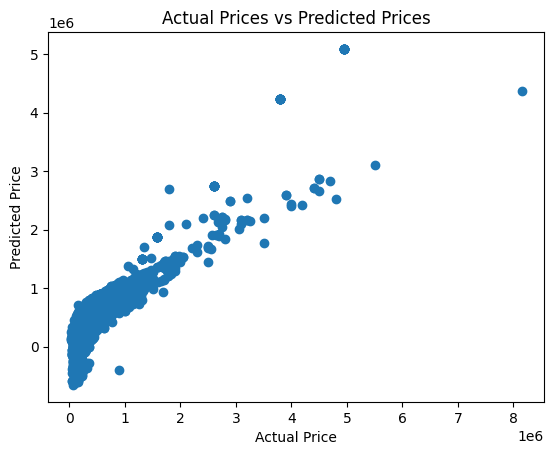

In [ ]:
plt.scatter(y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [ ]:
test_data_prediction = lr.predict(x_test_enc)

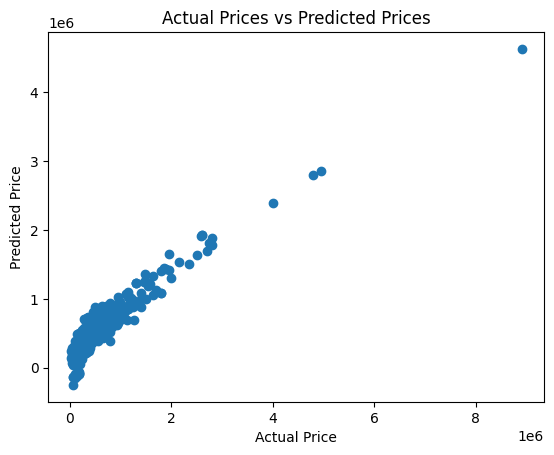

In [ ]:
plt.scatter(y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

# Model trainning (Lasso Regression)

In [ ]:
from sklearn.linear_model import Lasso
la = Lasso()

In [ ]:
la.fit(x_train_enc,y_train)

Lasso()

# Model Evaluation

In [ ]:
la.score(x_test_enc,y_test)

0.7949693131699402

In [ ]:
la.score(x_train_enc,y_train)

0.8243266222348568

# Predictive system

In [47]:
# 1. Pick one test sample
single_input = x_test.iloc[[69]]

# 2. Encode using trained target encoder
single_input_enc = te.transform(single_input)

# 3. Predict
predicted_price = lr.predict(single_input_enc)

print("Predicted Price:", predicted_price[0])


Predicted Price: 366664.5676180199


In [48]:
print(y_test.iloc[[69]])

2840    300000
Name: selling_price, dtype: int64


In [49]:
# 1. Pick one test sample
single_input = x_test.iloc[[0]]

# 2. Encode using trained target encoder
single_input_enc = te.transform(single_input)

# 3. Predict
predicted_price = la.predict(single_input_enc)

print("Predicted Price:", predicted_price[0])


Predicted Price: 267723.36296729


In [50]:
print(y_test.iloc[[69]])

2840    300000
Name: selling_price, dtype: int64
